# Challenge 2 — Water Potability
## SVM clásica compacta + benchmark de 64 muestras

Este notebook es la versión directa de los experimentos V2/V3. **No vuelve a ejecutar Optuna**: utiliza los hiperparámetros ganadores ya encontrados.

Contiene únicamente:

1. Carga del dataset y reconstrucción del holdout congelado.
2. Entrenamiento y evaluación de la mejor SVM clásica completa.
3. Selección fija de 64 muestras del pool de entrenamiento.
4. Validación cruzada de la SVM clásica de 64 muestras que posteriormente se comparará con la QSVM.

### Configuración ganadora de V3

- Imputación por mediana.
- `StandardScaler`.
- Distancia media a vecinos + puntaje de anomalía de `IsolationForest`.
- Limpieza `TomekLinks` únicamente en entrenamiento.
- SVM-RBF con `C=1.2519747115` y `gamma=0.0953978448`.
- Umbral recomendado de seguridad: `-0.3032644845`.

La rama de 64 muestras utiliza las **9 variables originales**, sin SMOTE ni características adicionales, para facilitar una comparación justa con QSVM.

## 1. Instalación, Drive e importaciones

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

%pip install -q -U imbalanced-learn kagglehub joblib

Mounted at /content/drive/


In [2]:
from __future__ import annotations

import json
from collections import Counter
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import TomekLinks
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pd.set_option('display.max_columns', 30)

## 2. Configuración fija

In [3]:
SEED = 42
HOLDOUT_SEED = 20260721
TARGET = 'Potability'
FEATURES = [
    'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
    'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity',
]

BASE_DIR = Path('/content/drive/MyDrive/Colab Notebooks')
ARTIFACT_DIR = BASE_DIR / 'artifacts_svm_compact'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Mejor configuración del modelo completo, obtenida en V3.
FULL_PARAMS = {
    'C': 1.2519747115129674,
    'gamma': 0.09539784477077082,
    'geometry_neighbors': 5,
}
FULL_THRESHOLDS = {
    'default_zero': 0.0,
    'max_f1_v3': -0.9516512901090459,
    'safety_recommended': -0.3032644845043456,
}

# Mejor configuración encontrada para la SVM de 64 muestras.
SMALL64_PARAMS = {
    'C': 0.06286312440262014,
    'gamma': 0.9805120710310026,
}
SMALL64_SELECTION_SEED = 6403
SMALL64_CV_SEED = 6411
SMALL64_FOLDS = 4

print('Artefactos:', ARTIFACT_DIR)
print('Modelo completo:', FULL_PARAMS)
print('Modelo 64:', SMALL64_PARAMS)

Artefactos: /content/drive/MyDrive/Colab Notebooks/artifacts_svm_compact
Modelo completo: {'C': 1.2519747115129674, 'gamma': 0.09539784477077082, 'geometry_neighbors': 5}
Modelo 64: {'C': 0.06286312440262014, 'gamma': 0.9805120710310026}


## 3. Dataset y holdout congelado

In [13]:
def resolve_dataset_path() -> Path:
    candidates = [
        Path('/content/drive/MyDrive/Colab Notebooks/water_potability.csv'),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate

    import kagglehub
    dataset_dir = Path(kagglehub.dataset_download('adityakadiwal/water-potability'))
    matches = list(dataset_dir.rglob('water_potability.csv'))
    if not matches:
        raise FileNotFoundError('No se encontró water_potability.csv')
    return matches[0]


DATA_PATH = resolve_dataset_path()
df = pd.read_csv(DATA_PATH)
assert list(df.columns) == FEATURES + [TARGET]
assert df.duplicated().sum() == 0
assert set(df[TARGET].unique()).issubset({0, 1})

X = df[FEATURES].copy()
y = df[TARGET].astype(int).copy()

# Se reutilizan los índices del holdout de V2/V3 cuando están disponibles.
locked_candidates = [
    BASE_DIR / 'artifacts_v2' / 'audit_test_v2_locked.csv',
    BASE_DIR / 'artifacts_v3' / 'reference_holdout_v2_locked.csv',
]
locked_path = next((p for p in locked_candidates if p.exists()), None)

if locked_path is not None:
    locked = pd.read_csv(locked_path)
    test_indices = pd.Index(locked['source_index'].astype(int))
    print('Holdout reutilizado:', locked_path)
else:
    _, test_indices = train_test_split(
        df.index,
        test_size=0.20,
        stratify=y,
        random_state=HOLDOUT_SEED,
    )
    test_indices = pd.Index(test_indices)
    print('Holdout reconstruido con semilla:', HOLDOUT_SEED)

train_indices = df.index.difference(test_indices, sort=False)
X_train, y_train = X.loc[train_indices].copy(), y.loc[train_indices].copy()
X_test, y_test = X.loc[test_indices].copy(), y.loc[test_indices].copy()

assert set(X_train.index).isdisjoint(X_test.index)

summary = pd.DataFrame({
    'split': ['training_pool', 'locked_holdout'],
    'samples': [len(y_train), len(y_test)],
    'class_0': [(y_train == 0).sum(), (y_test == 0).sum()],
    'class_1': [(y_train == 1).sum(), (y_test == 1).sum()],
})
display(summary)

Holdout reutilizado: /content/drive/MyDrive/Colab Notebooks/artifacts_v2/audit_test_v2_locked.csv


,split,samples,class_0,class_1
0,training_pool,2620,1598,1022
1,locked_holdout,656,400,256


## 4. Utilidades y pipeline ganador

In [5]:
class LocalGeometryFeatures(BaseEstimator, TransformerMixin):
    """Añade densidad local y anomalía usando únicamente el fold de entrenamiento."""

    def __init__(self, n_neighbors: int = 5, random_state: int = 42):
        self.n_neighbors = n_neighbors
        self.random_state = random_state

    def fit(self, X, y=None):
        arr = np.asarray(X, dtype=float)
        self.n_features_in_ = arr.shape[1]
        self._fit_X_ = arr.copy()

        k = min(max(2, self.n_neighbors + 1), len(arr))
        self.nn_ = NearestNeighbors(n_neighbors=k).fit(arr)
        self.isolation_ = IsolationForest(
            n_estimators=100,
            contamination='auto',
            random_state=self.random_state,
            n_jobs=1,
        ).fit(arr)
        return self

    def _transform(self, arr, training: bool):
        if training:
            distances, _ = self.nn_.kneighbors(arr)
            local_distance = distances[:, 1:].mean(axis=1)
        else:
            k = min(self.n_neighbors, self.nn_.n_samples_fit_)
            distances, _ = self.nn_.kneighbors(arr, n_neighbors=k)
            local_distance = distances.mean(axis=1)

        anomaly_score = -self.isolation_.score_samples(arr)
        return np.column_stack([arr, local_distance, anomaly_score])

    def fit_transform(self, X, y=None, **fit_params):
        arr = np.asarray(X, dtype=float)
        self.fit(arr, y)
        return self._transform(arr, training=True)

    def transform(self, X):
        arr = np.asarray(X, dtype=float)
        is_training_matrix = (
            arr.shape == self._fit_X_.shape
            and np.array_equal(arr, self._fit_X_, equal_nan=True)
        )
        return self._transform(arr, training=is_training_matrix)


def build_full_model() -> Pipeline:
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('local_geometry', LocalGeometryFeatures(
            n_neighbors=FULL_PARAMS['geometry_neighbors'],
            random_state=SEED,
        )),
        ('tomek', TomekLinks(sampling_strategy='auto')),
        ('svc', SVC(
            kernel='rbf',
            C=FULL_PARAMS['C'],
            gamma=FULL_PARAMS['gamma'],
            cache_size=1800,
        )),
    ])


def build_small64_model() -> SkPipeline:
    return SkPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('svc', SVC(
            kernel='rbf',
            C=SMALL64_PARAMS['C'],
            gamma=SMALL64_PARAMS['gamma'],
            cache_size=1000,
        )),
    ])


def metrics_from_scores(y_true, scores, threshold=0.0):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = (np.asarray(scores) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        'threshold': float(threshold),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'specificity': specificity,
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'average_precision': average_precision_score(y_true, scores),
        'roc_auc': roc_auc_score(y_true, scores),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }

## 5. SVM clásica completa: validación y holdout

,,threshold,accuracy,precision,recall,f1,specificity,balanced_accuracy,mcc,average_precision,roc_auc,tn,fp,fn,tp
split,policy,,,,,,,,,,,,,,
training_oof,default_zero,0.0000,0.6691,0.6334,0.3601,0.4591,0.8667,0.6134,0.2663,0.5872,0.6742,1385,213,654,368
locked_holdout,default_zero,0.0000,0.7104,0.7426,0.3945,0.5153,0.9125,0.6535,0.3695,0.6527,0.7402,365,35,155,101
training_oof,max_f1_v3,-0.9517,0.5225,0.4422,0.8571,0.5834,0.3085,0.5828,0.1882,0.5872,0.6742,493,1105,146,876
locked_holdout,max_f1_v3,-0.9517,0.5915,0.4871,0.8867,0.6288,0.4025,0.6446,0.3110,0.6527,0.7402,161,239,29,227
training_oof,safety_recommended,-0.3033,0.6542,0.5650,0.4932,0.5266,0.7572,0.6252,0.2577,0.5872,0.6742,1210,388,518,504
locked_holdout,safety_recommended,-0.3033,0.6982,0.6436,0.5078,0.5677,0.8200,0.6639,0.3464,0.6527,0.7402,328,72,126,130


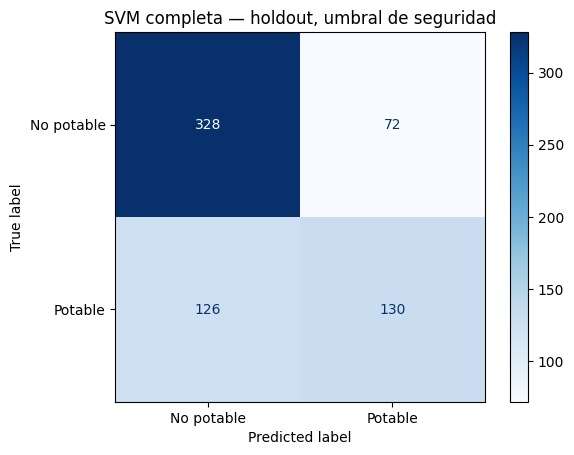

['/content/drive/MyDrive/Colab Notebooks/artifacts_svm_compact/full_svm_rbf_pipeline.joblib']

In [6]:
# Validación OOF sobre el pool de entrenamiento con hiperparámetros ya fijados.
full_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
full_oof_scores = cross_val_predict(
    build_full_model(),
    X_train,
    y_train,
    cv=full_cv,
    method='decision_function',
    n_jobs=-1,
)

full_model = build_full_model()
full_model.fit(X_train, y_train)
full_test_scores = full_model.decision_function(X_test)

rows = []
for policy, threshold in FULL_THRESHOLDS.items():
    train_metrics = metrics_from_scores(y_train, full_oof_scores, threshold)
    train_metrics.update({'split': 'training_oof', 'policy': policy})
    rows.append(train_metrics)

    test_metrics = metrics_from_scores(y_test, full_test_scores, threshold)
    test_metrics.update({'split': 'locked_holdout', 'policy': policy})
    rows.append(test_metrics)

full_results = pd.DataFrame(rows).set_index(['split', 'policy'])
full_results.to_csv(ARTIFACT_DIR / 'full_svm_metrics.csv')
display(full_results.round(4))

# La política recomendada para agua potable es la de seguridad.
recommended_threshold = FULL_THRESHOLDS['safety_recommended']
recommended_pred = (full_test_scores >= recommended_threshold).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    recommended_pred,
    labels=[0, 1],
    display_labels=['No potable', 'Potable'],
    cmap='Blues',
)
plt.title('SVM completa — holdout, umbral de seguridad')
plt.show()

joblib.dump(full_model, ARTIFACT_DIR / 'full_svm_rbf_pipeline.joblib')

# Parte 2 — SVM clásica con 64 muestras

Las 64 muestras se extraen **solo del pool de entrenamiento**: 32 no potables y 32 potables. Se usan nueve variables originales y cuatro folds fijos. Estos mismos índices y folds serán la base de la futura QSVM.

In [7]:
idx_0 = y_train[y_train == 0].sample(n=32, random_state=SMALL64_SELECTION_SEED).index
idx_1 = y_train[y_train == 1].sample(n=32, random_state=SMALL64_SELECTION_SEED).index
small64_indices = np.r_[idx_0.to_numpy(), idx_1.to_numpy()]
np.random.default_rng(SMALL64_SELECTION_SEED).shuffle(small64_indices)

X_64 = X_train.loc[small64_indices, FEATURES].copy()
y_64 = y_train.loc[small64_indices].copy()

assert Counter(y_64) == Counter({0: 32, 1: 32})
assert set(small64_indices).isdisjoint(X_test.index)

cv64 = StratifiedKFold(
    n_splits=SMALL64_FOLDS,
    shuffle=True,
    random_state=SMALL64_CV_SEED,
)
folds64 = list(cv64.split(X_64, y_64))

fold_assignment = pd.DataFrame({
    'source_index': small64_indices,
    TARGET: y_64.to_numpy(dtype=int),
    'validation_fold': -1,
})
for fold_id, (_, valid_pos) in enumerate(folds64):
    fold_assignment.loc[valid_pos, 'validation_fold'] = fold_id

raw64 = X_64.copy()
raw64.insert(0, 'source_index', raw64.index)
raw64[TARGET] = y_64.to_numpy(dtype=int)

display(raw64.head())
display(fold_assignment.sort_values('validation_fold').head(12))

,source_index,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
127,127,7.371085,207.716824,24913.837166,9.616330,362.300180,363.168538,11.542662,67.720704,4.412590,0
41,41,5.331940,194.874065,16658.876503,7.993830,316.675162,335.120398,10.180514,59.572714,4.434820,0
3183,3183,7.164478,213.002441,32751.928963,6.292148,NaN,490.933121,12.683767,58.252613,4.998203,1
1619,1619,6.962325,205.183020,35229.077002,5.088710,254.729932,360.058960,13.617560,NaN,4.526768,1
549,549,NaN,164.378433,15908.561870,11.208688,NaN,360.814296,17.239577,60.179119,4.380978,0


,source_index,Potability,validation_fold
1,41,0,0
2,3183,1,0
10,3103,0,0
8,378,1,0
12,3137,1,0
26,414,0,0
21,1533,1,0
23,1458,0,0
25,628,0,0
31,2664,0,0


## 6. Validación cruzada fija de la SVM de 64 muestras

,threshold,accuracy,precision,recall,f1,specificity,balanced_accuracy,mcc,average_precision,roc_auc,tn,fp,fn,tp
fold,,,,,,,,,,,,,,
0,0.0,0.5625,0.5333,1.000,0.6957,0.125,0.5625,0.2582,0.7791,0.7344,1,7,0,8
1,0.0,0.5000,0.5000,1.000,0.6667,0.000,0.5000,0.0000,0.6278,0.5938,0,8,0,8
2,0.0,0.5625,1.0000,0.125,0.2222,1.000,0.5625,0.2582,0.7494,0.6875,8,0,7,1
3,0.0,0.5625,0.5333,1.000,0.6957,0.125,0.5625,0.2582,0.6952,0.7344,1,7,0,8


,mean,std
accuracy,0.5469,0.0312
precision,0.6417,0.2394
recall,0.7812,0.4375
f1,0.5700,0.2323
specificity,0.3125,0.4621
balanced_accuracy,0.5469,0.0312
mcc,0.1936,0.1291
average_precision,0.7129,0.0665
roc_auc,0.6875,0.0663


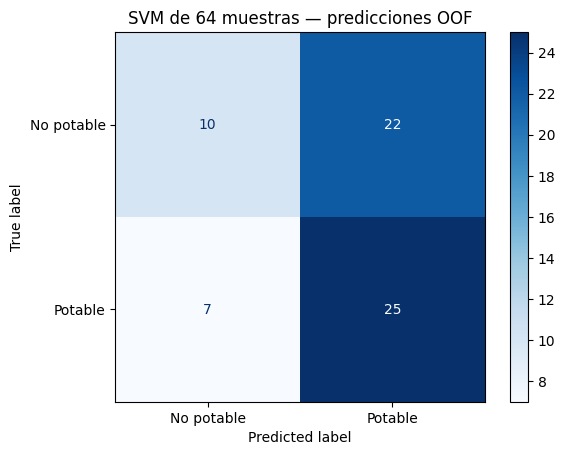

In [8]:
oof64_scores = np.full(len(y_64), np.nan)
fold_rows = []

for fold_id, (train_pos, valid_pos) in enumerate(folds64):
    model = build_small64_model()
    model.fit(X_64.iloc[train_pos], y_64.iloc[train_pos])
    scores = model.decision_function(X_64.iloc[valid_pos])
    oof64_scores[valid_pos] = scores

    fold_metrics = metrics_from_scores(
        y_64.iloc[valid_pos],
        scores,
        threshold=0.0,
    )
    fold_metrics['fold'] = fold_id
    fold_rows.append(fold_metrics)

assert not np.isnan(oof64_scores).any()
fold_metrics64 = pd.DataFrame(fold_rows).set_index('fold')
summary64 = pd.DataFrame({
    'mean': fold_metrics64.mean(numeric_only=True),
    'std': fold_metrics64.std(numeric_only=True),
})

display(fold_metrics64.round(4))
display(summary64.loc[[
    'accuracy', 'precision', 'recall', 'f1', 'specificity',
    'balanced_accuracy', 'mcc', 'average_precision', 'roc_auc',
]].round(4))

oof64_pred = (oof64_scores >= 0.0).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_64,
    oof64_pred,
    labels=[0, 1],
    display_labels=['No potable', 'Potable'],
    cmap='Blues',
)
plt.title('SVM de 64 muestras — predicciones OOF')
plt.show()

## 7. Ajuste final y exportación para la futura QSVM

In [9]:
# Modelo final clásico entrenado con las 64 muestras.
svm64_model = build_small64_model()
svm64_model.fit(X_64, y_64)

# Exportaciones necesarias para reproducir exactamente la comparación.
raw64.to_csv(ARTIFACT_DIR / 'svm64_training_raw.csv', index=False)
fold_assignment.to_csv(ARTIFACT_DIR / 'svm64_fixed_cv_folds.csv', index=False)
fold_metrics64.to_csv(ARTIFACT_DIR / 'svm64_cv_metrics.csv')

pd.DataFrame({
    'source_index': small64_indices,
    TARGET: y_64.to_numpy(dtype=int),
    'oof_decision_score': oof64_scores,
    'oof_prediction': oof64_pred,
}).to_csv(ARTIFACT_DIR / 'svm64_oof_predictions.csv', index=False)

joblib.dump(svm64_model, ARTIFACT_DIR / 'svm64_rbf_pipeline.joblib')

manifest = {
    'full_model': {
        'params': FULL_PARAMS,
        'thresholds': FULL_THRESHOLDS,
        'holdout_seed': HOLDOUT_SEED,
    },
    'svm64': {
        'selection_method': 'fixed_stratified_random_from_training_pool',
        'selection_seed': SMALL64_SELECTION_SEED,
        'cv_seed': SMALL64_CV_SEED,
        'folds': SMALL64_FOLDS,
        'class_counts': {str(k): int(v) for k, v in Counter(y_64).items()},
        'features': FEATURES,
        'params': SMALL64_PARAMS,
        'important_qsvm_rule': (
            'La imputación y el escalado deben volver a ajustarse dentro de cada fold '
            'cuando se ejecute la comparación con QSVM.'
        ),
    },
}
with open(ARTIFACT_DIR / 'compact_manifest.json', 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print('Archivos generados:')
for path in sorted(ARTIFACT_DIR.iterdir()):
    print('-', path.name)

Archivos generados:
- compact_manifest.json
- full_svm_metrics.csv
- full_svm_rbf_pipeline.joblib
- svm64_cv_metrics.csv
- svm64_fixed_cv_folds.csv
- svm64_oof_predictions.csv
- svm64_rbf_pipeline.joblib
- svm64_training_raw.csv


## Lectura de resultados

- Para el modelo completo, la política `safety_recommended` es la principal porque reduce falsos positivos de potabilidad.
- La política `max_f1_v3` sirve como referencia académica, pero acepta una especificidad mucho menor.
- La SVM de 64 se valida únicamente con sus cuatro folds fijos. **No se deben escoger nuevas muestras según su desempeño**, porque eso sesgaría la futura comparación con QSVM.
- La futura QSVM deberá usar exactamente `svm64_training_raw.csv` y `svm64_fixed_cv_folds.csv`, ajustando el preprocesamiento dentro de cada fold.